<a href="https://colab.research.google.com/github/stella1298/AIFFEL_Quest_EPA/blob/master/DL/DL01/Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── (선택) 구글 드라이브 마운트 — 승인 창이 뜨면 [액세스 허용] ──
from google.colab import drive
drive.mount('/content/drive')

import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=vjybnwvx').read().decode())

Mounted at /content/drive
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료 — 이 탭은 열어두세요.
✅ 연결됐습니다 — 웹앱 탭으로 돌아가면 자동으로 이어집니다.


#- 프로젝트 1의 회귀모델 예측정확도가 기준 이상 높게 나왔는가?
#- MSE 손실함수값 3000 이하를 달성
---


In [348]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [349]:
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [350]:
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [351]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [352]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [353]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [354]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [355]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [356]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

# * LEARNING_RATE = 0.001에서 0.1로 수정
---
- 가중치가 너무 느리게 학습되는 문제를 개선하기 위해 숫자를 높임.


In [357]:
LEARNING_RATE = 0.1

# * range 부분에서 1001에서 7001로 변경하였다.
---

- 학습횟수를 늘리기 위해서 반복 횟수를 1001에서 7001로 늘렸다.

In [358]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 7001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5379.4028
Iteration 200 : Loss 4877.0364
Iteration 300 : Loss 4503.4923
Iteration 400 : Loss 4222.0440
Iteration 500 : Loss 4006.8547
Iteration 600 : Loss 3839.7037
Iteration 700 : Loss 3707.7019
Iteration 800 : Loss 3601.6966
Iteration 900 : Loss 3515.1572
Iteration 1000 : Loss 3443.3970
Iteration 1100 : Loss 3383.0283
Iteration 1200 : Loss 3331.5813
Iteration 1300 : Loss 3287.2376
Iteration 1400 : Loss 3248.6423
Iteration 1500 : Loss 3214.7730
Iteration 1600 : Loss 3184.8465
Iteration 1700 : Loss 3158.2539
Iteration 1800 : Loss 3134.5139
Iteration 1900 : Loss 3113.2400
Iteration 2000 : Loss 3094.1168
Iteration 2100 : Loss 3076.8830
Iteration 2200 : Loss 3061.3193
Iteration 2300 : Loss 3047.2394
Iteration 2400 : Loss 3034.4829
Iteration 2500 : Loss 3022.9109
Iteration 2600 : Loss 3012.4021
Iteration 2700 : Loss 3002.8494
Iteration 2800 : Loss 2994.1585
Iteration 2900 : Loss 2986.2453
Iteration 3000 : Loss 2979.0350
Iteration 3100 : Loss 2972.4606
Iteration 3200 : 

#  --> mse값이 2873으로 낮아졌다.

In [359]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2873.928490422932)

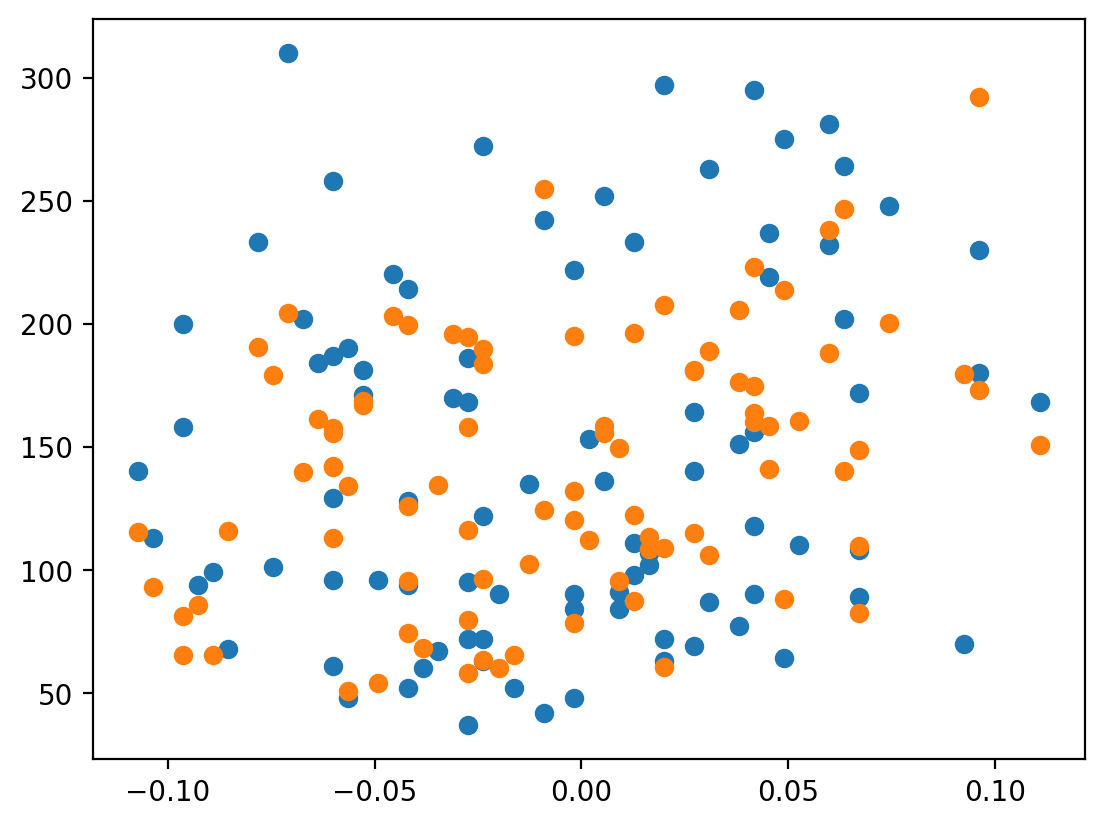

In [360]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()


# - 프로젝트 2의 회귀모델 예측정확도가 기준 이상 높게 나왔는가?
# - RMSE 값 150 이하를 달성
---

In [361]:
import gdown
import pandas as pd

gdown.download('https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG', 'train.csv', quiet=False)
train = pd.read_csv("train.csv")
train.info()

Downloading...
From: https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG
To: /content/train.csv
100%|██████████| 648k/648k [00:00<00:00, 98.3MB/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


# ** 요일 정보 추가
- train['dayofweek'] = train['datetime'].dt.dayofweek
- 요일에 따라 자전거 대여량이 달라질 수 있으므로 요일 정보 추가

In [362]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

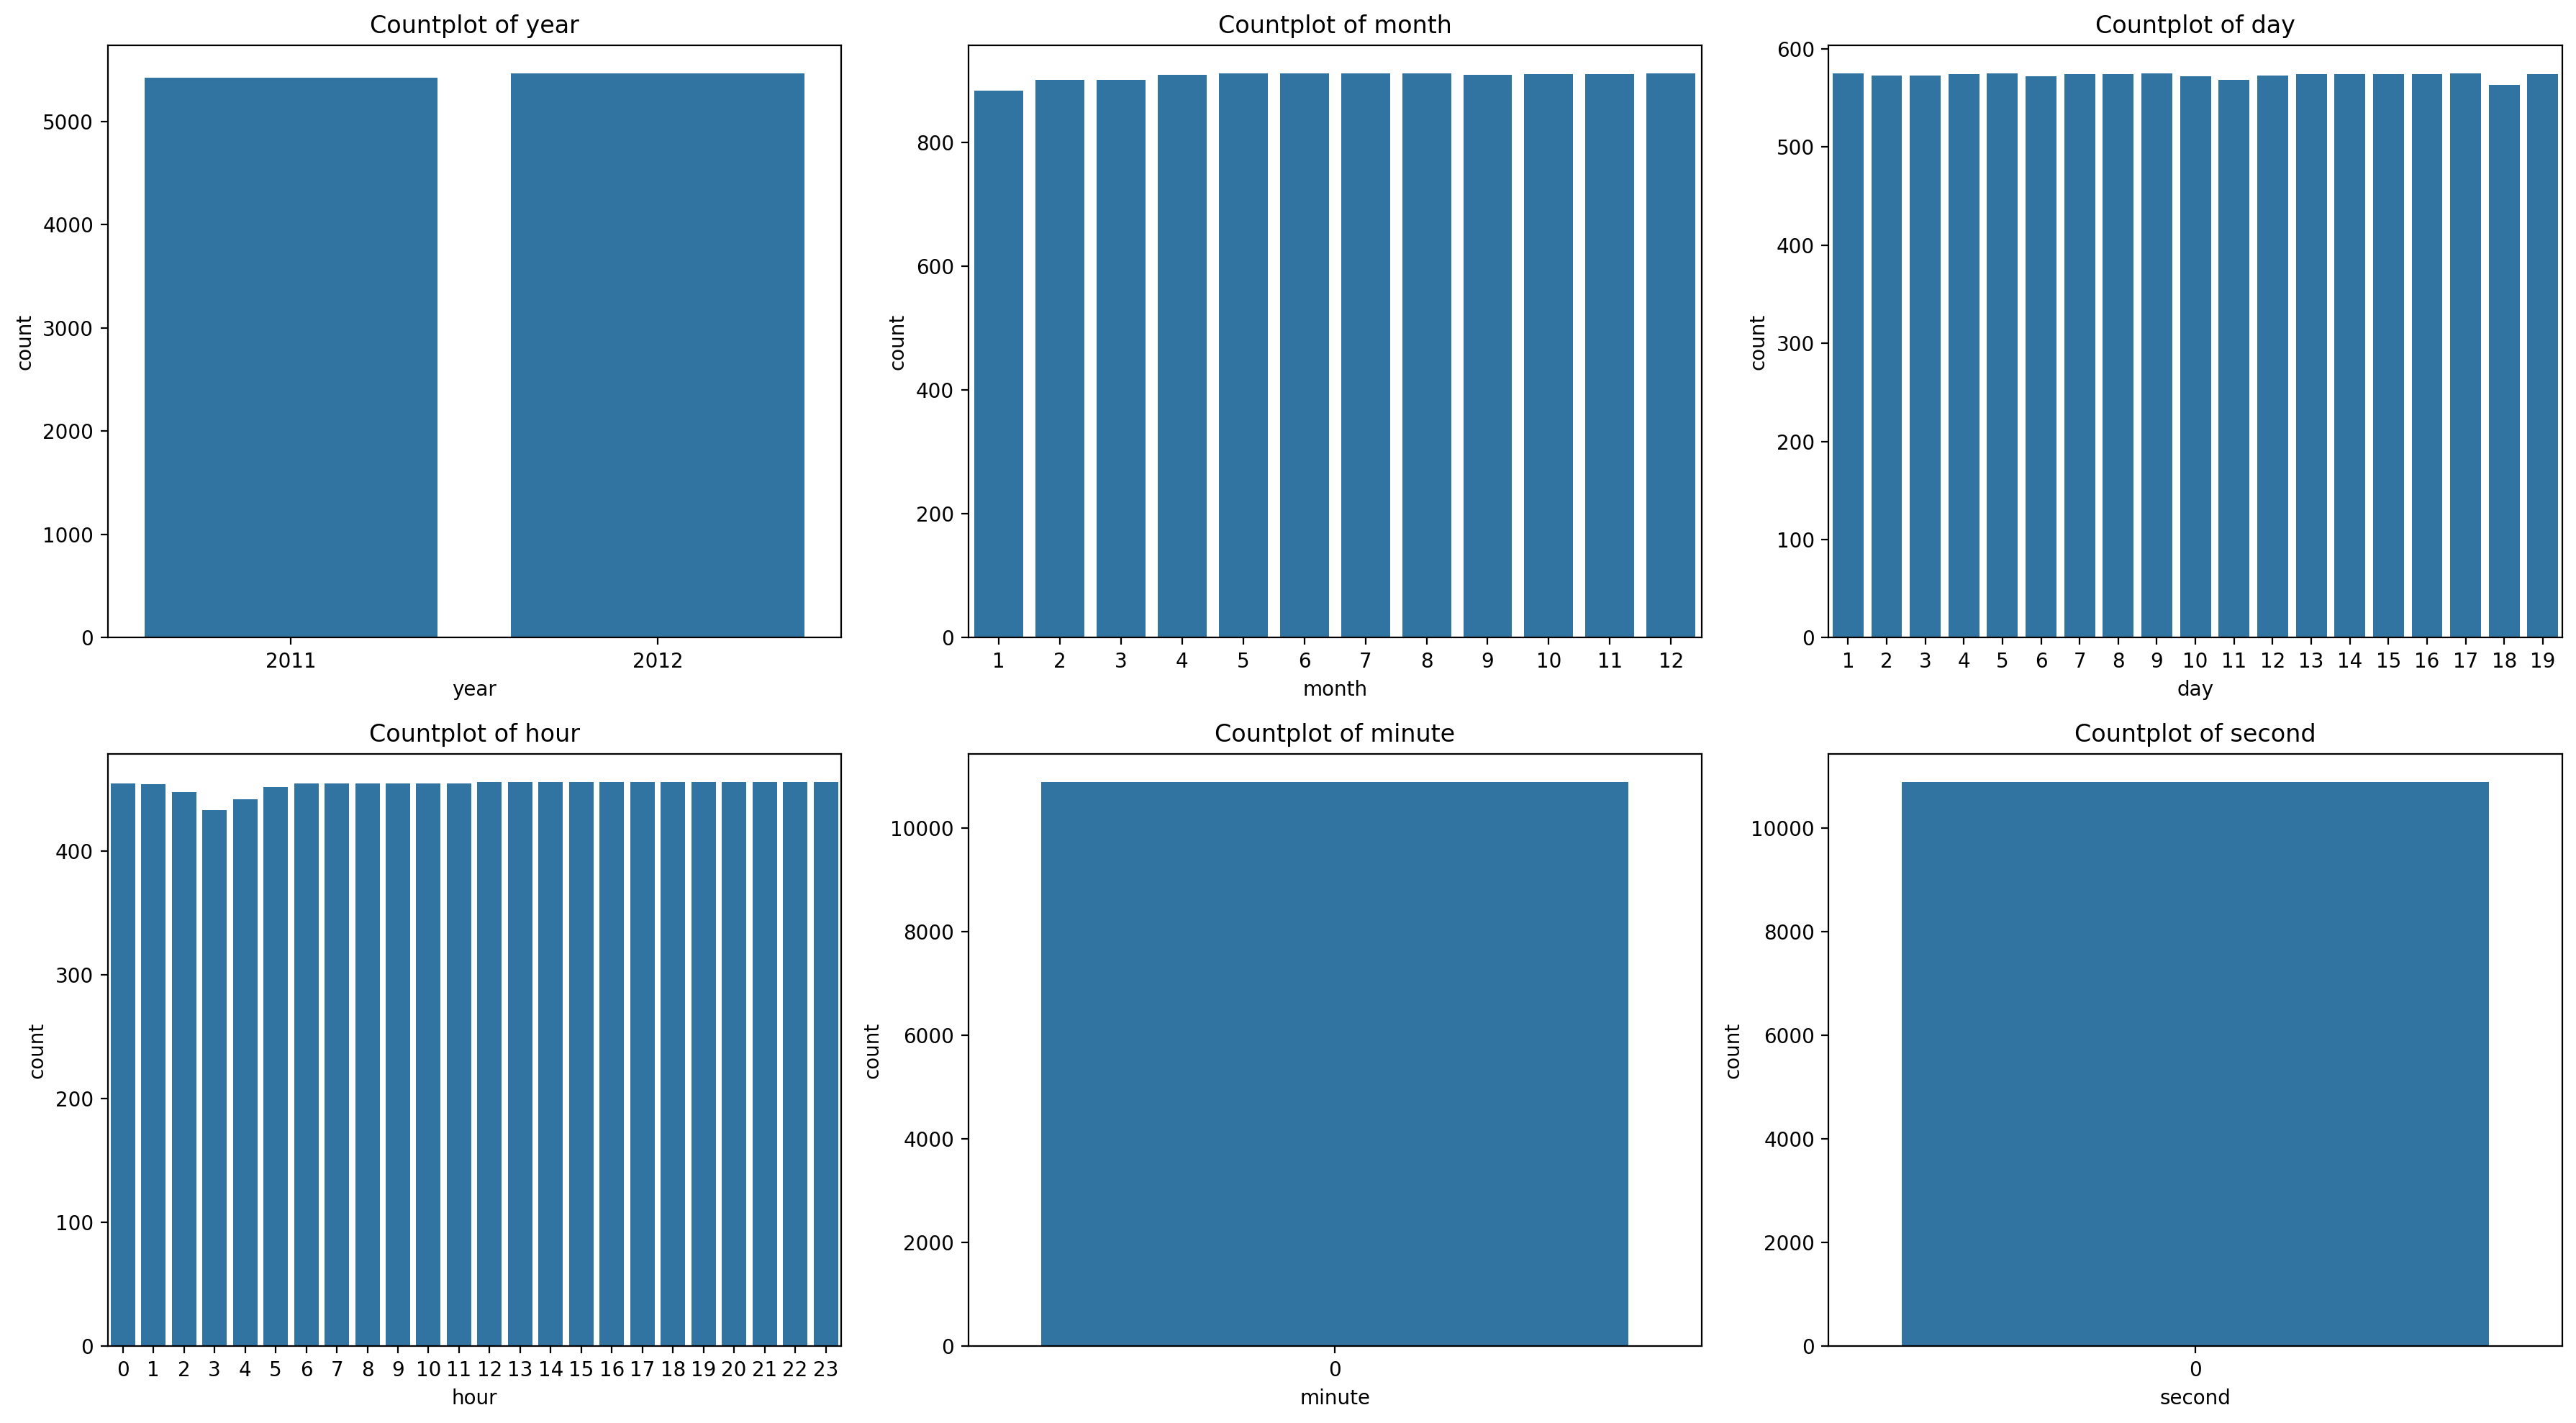

In [313]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

# ** Feature 변경
---

- features = ['year', 'month', 'hour',
'dayofweek', 'season', 'holiday', 'workingday', 'weather', 'atemp',
'temp', 'humidity', 'windspeed']
- 계절, 공휴일, 근무일, 날씨, 체감온도 등 대여량에 영향을 주는 변수를 추가하고, 의미가 적은 day는 제거한다.

In [314]:
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [315]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [316]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435438
RMSE: 141.2865946027274


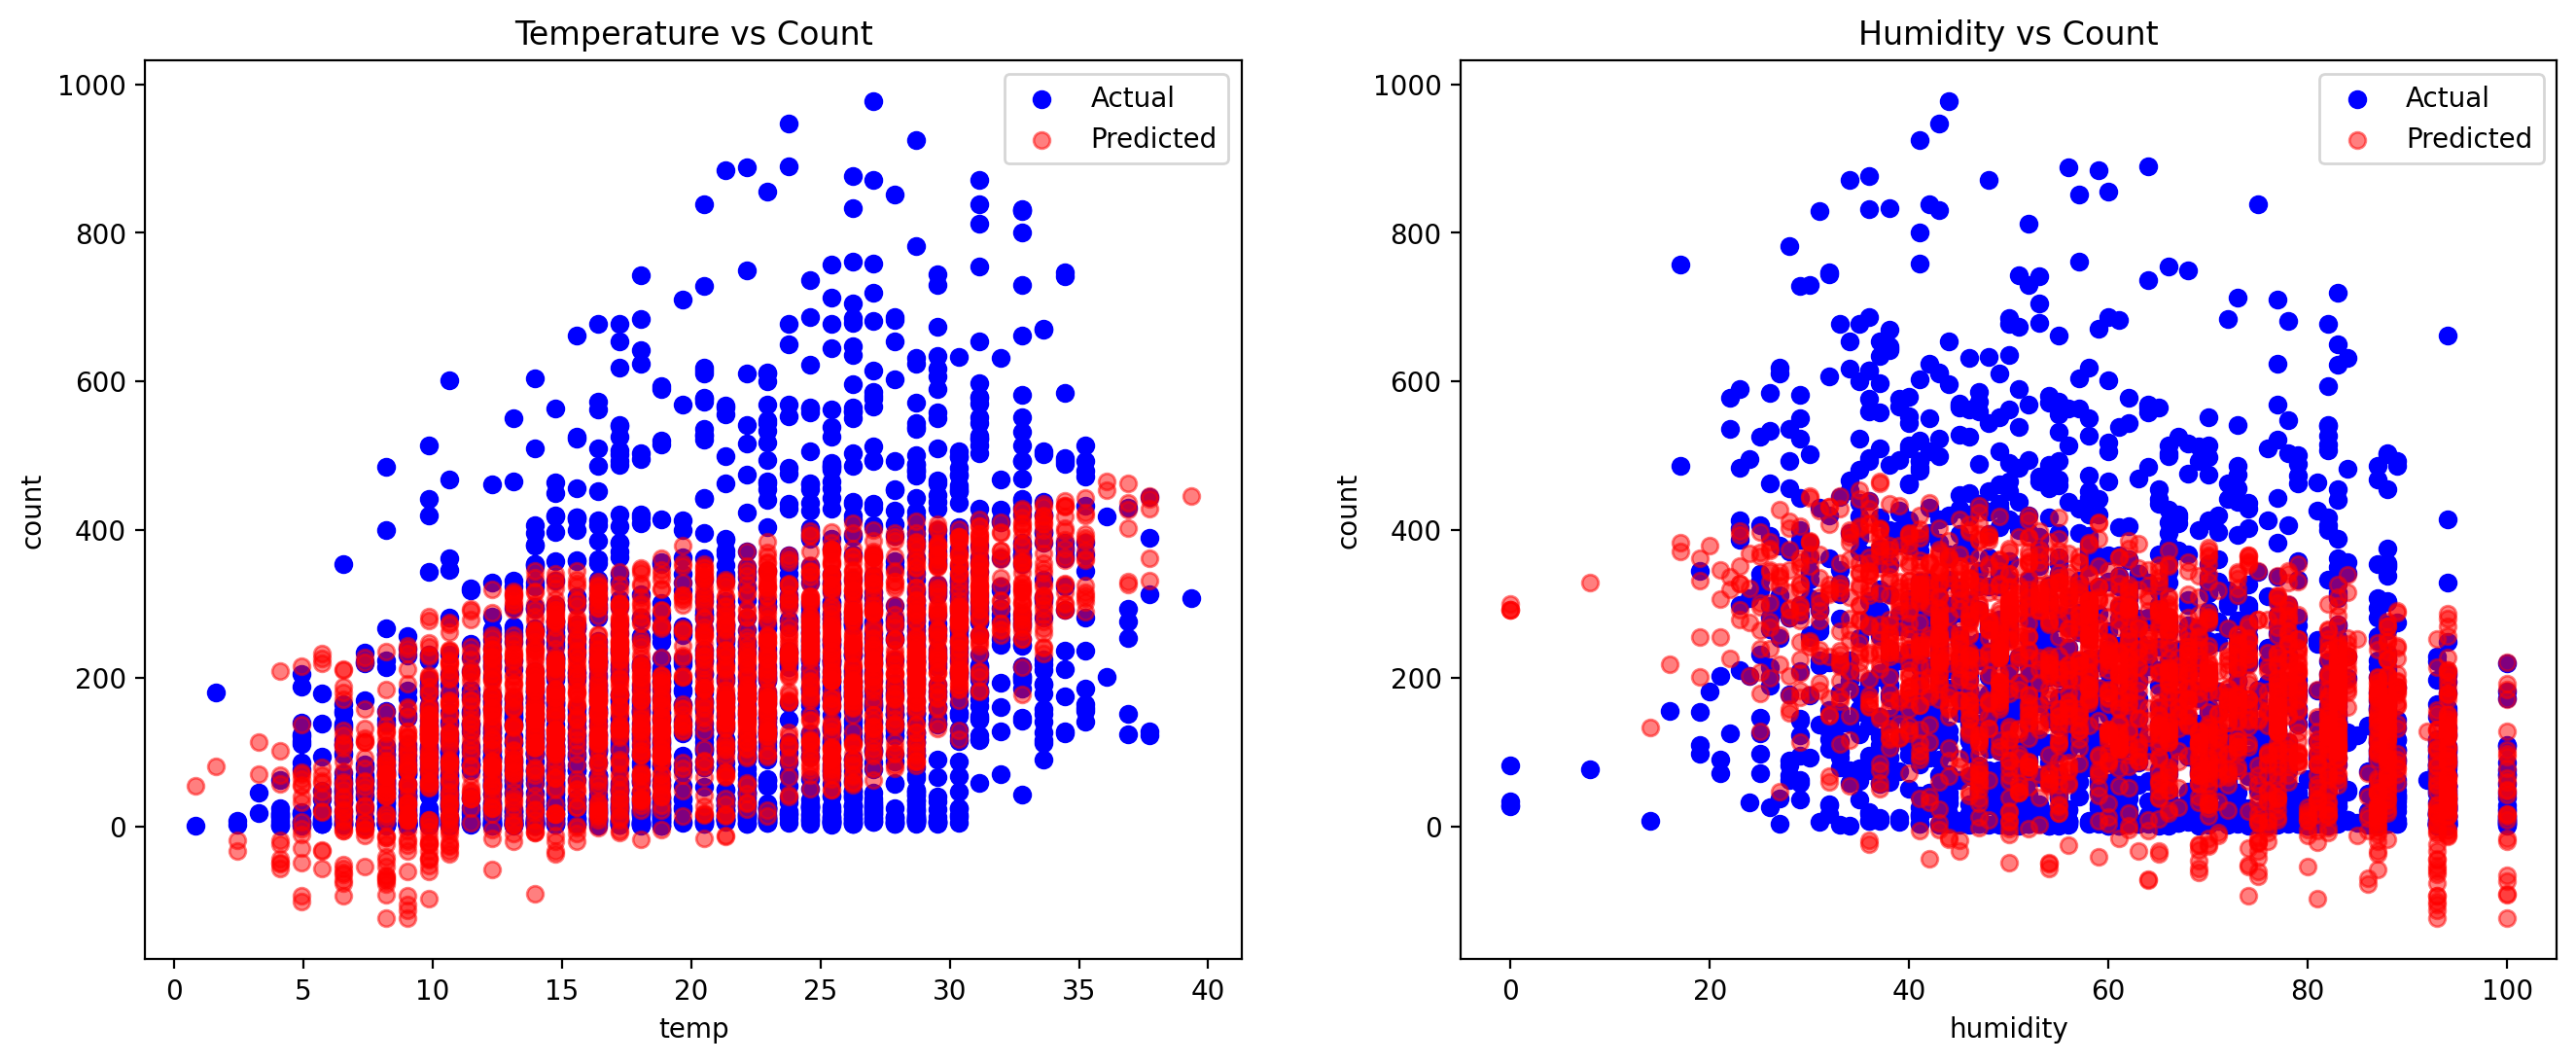

In [317]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()